In [20]:
# ================================
# STEP: Create 3-Class Dataset
# ================================
np.random.seed(42)

data = {
    'age': np.random.randint(20, 65, 300),
    'income': np.random.randint(30000, 120000, 300),
    'loan_amount': np.random.randint(5000, 50000, 300),
    'credit_score': np.random.randint(300, 850, 300),
    'employment_years': np.random.randint(0, 30, 300),
    'debt_to_income_ratio': np.random.uniform(0.1, 0.5, 300),

    # 🔥 CHANGE HERE → 3 CLASSES
    'loan_status': np.random.choice([0,1,2], 300, p=[0.3,0.4,0.3])
}

df = pd.DataFrame(data)

print("Dataset Created Successfully")
df.head()

Dataset Created Successfully


,age,income,loan_amount,credit_score,employment_years,debt_to_income_ratio,loan_status
0,58,76214,40307,408,12,0.477093,0
1,48,116416,12056,445,1,0.359859,0
2,34,100271,16516,410,22,0.343095,0
3,62,74064,49261,527,4,0.305075,1
4,27,100091,6542,410,10,0.192268,1


In [21]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # 🔥 IMPORTANT
)

In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression # Import a classifier
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a simple model (e.g., Logistic Regression) to get predictions
model = LogisticRegression(max_iter=1000, random_state=42) # Added max_iter for convergence
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])

print("Confusion Matrix (3x3):")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix (3x3):
[[ 1 22  2]
 [ 0 32  7]
 [ 0 22  4]]
Accuracy: 0.4111111111111111


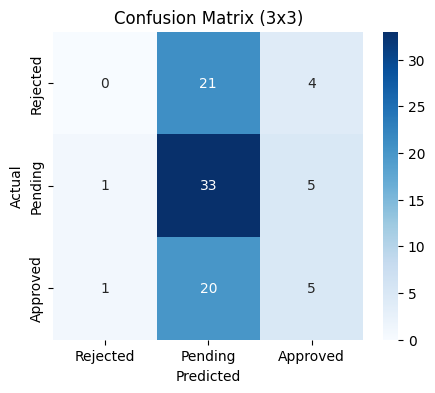

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected','Pending','Approved'],
    yticklabels=['Rejected','Pending','Approved']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (3x3)")
plt.show()